# Naive Bayes Classification to Predict Titanic Survival

**Deep Dive Coding Data Science Bootcamp Sample Project**

---
Robert Citek - October 5th, 2026


## Problem Definition

State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.  Mention which model will be used, if known.

## Data Collection/Sources

### Data Overview

This data comes from [Kaggle](https://www.kaggle.com/c/titanic/data), which was then copied to AWS for easy access.

https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv


### Imports

In [1]:
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

### File Paths

Create a variable `url` that contains the web link to the CSV data

In [2]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'    # insert url here
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'

### Load data

Load the data into a data frame named `titanic_df`.

In [3]:
# load data
titanic_df = pd.read_csv( url )
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### head

Look at the first few rows

In [4]:
# first few rows
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### tail

Look at the last few rows


In [5]:
# last few rows
titanic_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### shape


In [6]:
# shape of data frame
titanic_df.shape

(891, 12)

### size


In [7]:
# size of data frame
titanic_df.size

10692

In [8]:
titanic_df.size?

In [9]:
np.prod(titanic_df.shape)

np.int64(10692)

### Summary meta-data

Run the `info()` method on the data frame.


In [10]:
# display meta-data
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Summary statistics

Summary statistics give you a quick overview of the data.  Some items to spot check:
- the Target:
  - look for nulls
    - null will be culled
  - look at min, max, median, and mean
    - is it a categorical field masquerading as a number?
- the Features:
  - numerical
    - look at min, max, median, and mean
      - a min=1 and max=count suggests an ID
  - categorical
    - look at unique and freq
      - freq=1, unique=count suggests an ID
      - freq=count suggests a meaningless feature

Run the `describe()` method on the data frame.

In [11]:
# display summary statistics
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### target value_counts()


The target should be the first field that you look at.  Its data type will tell you what kind of machine learning problem this is ( classification or regression. ) Any nulls should be culled.  You can check for any skew in the data set.

In [12]:
titanic_df.value_counts?

In [13]:
# value_counts on target ; include nulls
titanic_df['Survived'].value_counts( dropna = False )

,count
Survived,
0,549
1,342


In [14]:
# normalized value_counts on target ; include nulls
titanic_df['Survived'].value_counts( normalize = True, dropna = False )

,proportion
Survived,
0,0.616162
1,0.383838


### Nulls



In [15]:
# look for nulls
titanic_df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [16]:
# look for nulls
titanic_df.isnull().sum() * 1000
# .sort_values(ascending=False)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177000
SibSp,0
Parch,0
Ticket,0
Fare,0


In [17]:
# look for nulls, displaying relative frequency
null_sum = titanic_df.isnull().sum()
null_freq = null_sum / titanic_df.shape[0] * 100
null_freq.sort_values()

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Embarked,0.224467


### dtypes - column data types

Which data types would be appropriate for Gaussian Naive Bayes?


In [18]:
# display data types
titanic_df.dtypes # integers and floats, NOT objects (numerical data)

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


### Unique elements


If the total number of unique items in a field equals the number of rows, that suggests those fields are unique IDs ( e.g. names, IDs ) and should be dropped.


In [19]:
titanic_df['PassengerId'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [20]:
# number of unique elements in a column
len( titanic_df['PassengerId'].unique() )

891

In [21]:
# check our answer
titanic_df['PassengerId'].size

891

In [22]:
titanic_df.shape[0]

891

In [23]:
titanic_df.nunique(axis='rows')

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


## Data Cleaning


### Backup #1


In [24]:
# make backup
titanic_df_bak = titanic_df.copy()
titanic_df_bak

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [25]:
# restore from backup
titanic_df = titanic_df_bak
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Keep only the target and one feature

Select `Survived` for the target and `Age` for the single feature

In [26]:
# select the target and one feature
titanic_df[['Survived', 'Age']]

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


In [27]:
titanic_df = titanic_df[['Survived', 'Age']]
titanic_df

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


### Backup #2


In [28]:
# make backup
data_cleaning_titanic_df = titanic_df.copy()
data_cleaning_titanic_df

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


In [30]:
# restore from backup
titanic_df = data_cleaning_titanic_df
titanic_df

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


### Address any rows with nulls

- If the number of nulls in a column is low, it would be easiest to drop the row.
- If the number of nulls in a column is high, it would be easiest to drop the column.
- If the number of nulls in a column is between the low and high, one should impute values for the nulls.


In [31]:
titanic_df.isnull().sum().sort_values(ascending=False)

,0
Age,177
Survived,0


#### Impute

Impute with the median.


In [35]:
# Calculate the median
# titanic_df['PassengerId'].size
median_age = titanic_df['Age'].median()
median_age

28.0

In [47]:
# Assign median to nulls
# median_now_nulls = titanic_df['Age'].fillna(value=median_age)
titanic_df['Age'].fillna(median_age, inplace=True)
# .median()
titanic_df

/tmp/ipykernel_3140/2569905042.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(median_age, inplace=True)


,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,28.0
889,1,26.0


In [48]:
# Verify there are no nulls
titanic_df['Age'].isnull().sum()

np.int64(0)

In [49]:
# Verify median is about the same as before
titanic_df['Age'].median()

28.0

In [45]:
# type(median_now_nulls)

pandas.core.series.Series

## Exploratory Data Analysis


GNB has two requirements:
1. the features are normally distributed
1. the features are not correlated with each other





### normal distribution of features: histogram


<Axes: >

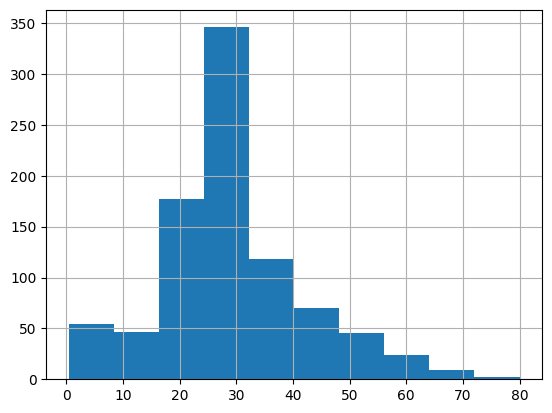

In [50]:
# Display a histogram
titanic_df['Age'].hist()
# normally distributed with a positive skew

### No correlation with single feature



## Processing



In [51]:
# Split data frame into target and features
target   = titanic_df['Survived']
features = titanic_df['Age']

In [52]:
# Verify features
features

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [53]:
# Verify target
target

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


### Single Cross Validation

Run a single Cross Validation

#### Train Test Split

In [58]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(features,target,test_size=0.25)

In [59]:
# Verify shape of each data set from Train Test Split
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((668,), (223,), (668,), (223,))

In [60]:
train_test_split?

In [66]:
X_train

,Age
103,33.0
630,80.0
30,40.0
220,16.0
331,45.5
...,...
561,40.0
384,28.0
177,50.0
108,38.0


#### Model


In [62]:
# Create an empty GNB model
modelGNB = GaussianNB()

In [63]:
modelGNB

GaussianNB()

#### Fit


In [65]:
# Train ( fit ) the model
modelGNB.fit(pd.DataFrame(X_train), y_train)

GaussianNB()

#### Prediction


In [83]:
# Make predicitons using the model
y_pred = modelGNB.predict(pd.DataFrame(X_test))
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0])

#### Performance


We'll meassure accuracy, which is the proportions of the number correctly predicted, which is mathematically the same as one minus the proportion incorrectly predicted.

In [84]:
# Calculate the accuracy
pred_accuracy = metrics.accuracy_score(y_test,y_pred)
pred_accuracy

0.6681614349775785

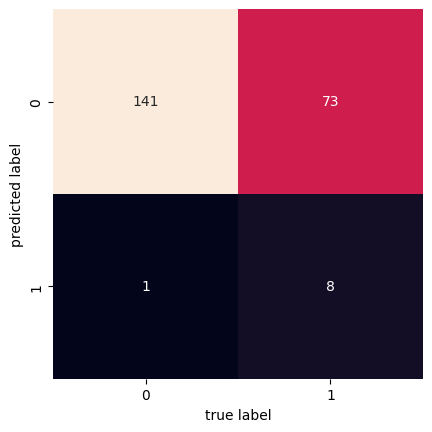

In [85]:
# Display a confusion matrix
# plt.figure(figsize=(8,8))
mat = metrics.confusion_matrix(y_test,y_pred)
sns.heatmap(mat.T,
  square=True,
  annot=True,
  fmt='d',
  cbar=False,
  # xticklabels=dataset.target_names,
  # yticklabels=dataset.target_names
)
plt.xlabel('true label')
plt.ylabel('predicted label');

## Communication of Results

### Conclusion:

#### Summary:
x-axis is what our predictions were, and y-axis is what we actually got. 141 actually survived; 73 are false positives (modeled to survive but actually perished); 1 was predicted to perish but actually survived (false negatives); and 8 were correctly modeled to have perished.

Noteworthy Points:
- The model had a large number of false positives relative to the sample size

### Results:
**Accuracy Score: 66.8%**

**Confusion Matrix:**
- **True  Positive: 141 / 223**
- **False Positive: 73  / 223**
- **False Negative: 1   / 223**
- **True  Negative: 8   / 223**

### Future work:

Do more passes and try out different techniques to improve accuracy score of model.

